# Comparison to the Rivkind & Barak reservoir model

Implements a reservoir RNN trained by a least-squares readout to embed a ring attractor,
and sweeps the reservoir gain `g` to compare its behaviour against our model.

**Produces** Supplementary Figure S16 (`reservoir_rnn_dynamics.png`).

**Reads** nothing; the five reservoirs are trained from scratch on each run, which makes
this the slowest notebook to rerun. The committed figure was made on a GPU and only a GPU
run reproduces it exactly, because torch draws different random numbers on CPU.

## Why this comparison

The reservoir model differs from our model in three ways: it achieves tuning-curve heterogeneity only by pushing the network toward chaos, it admits just a one-dimensional family of solutions, and it gives no principled reason for its random-plus-low-rank connectivity. These differences predict different weight spectra (a random bulk versus no bulk) and different eigenvector structure, and those predictions are what Supplementary Figure S16 tests.

## Reservoir RNN with trained readout

The full model: a random reservoir `J ~ g/√N`, Fourier feedback weights `U`, open-loop teacher-forced training to a steady state, ridge-regression readout weights `V`, and closed-loop autonomous dynamics under `J + (1/N) U Vᵀ`. Plotting helpers are methods on the class.

In [1]:
# Regeneration switches (default off so a normal run cannot overwrite committed figures/caches):
SAVE_FIGURES = False

import torch
import numpy as np
import matplotlib.pyplot as plt
from ring import style


class ReservoirRNN:
    """
    Reservoir Computing RNN implementing DMFT model with consolidated methods.
    Trains in open-loop mode, learns readout weights, operates in closed-loop.
    """
    
    def __init__(self, N, g, K, P, embedding, teacher_signal=None, device='cuda' if torch.cuda.is_available() else 'cpu'):
        """
        Initialize ReservoirRNN with specified parameters.
        
        Args:
            teacher_signal: Custom teacher signal [P, K] or None for Fourier default
        """
        self.N, self.g, self.K, self.P = N, g, K, P
        self.embedding = embedding.lower()
        self.device = device
        
        # Initialize weights
        self.J = torch.randn(N, N, device=device) * g / np.sqrt(N)  # [N, N]
        self.U = self._init_feedback_weights()  # [N, K]
        
        # Set teacher signal
        self.z_bar = (teacher_signal.to(device) if teacher_signal is not None 
                     else self._generate_fourier_teacher())  # [P, K]
        self._is_fourier_teacher = teacher_signal is None
        
        # Learned components (set during training)
        self.V = None  # [N, K] - readout weights
        self.J_learned = None  # [N, N] - combined connectivity
        self.X_ss = None  # [N, P] - steady-state activities
        self.Gamma = None  # [P, P] - activity correlation matrix
    
    def _init_feedback_weights(self):
        """
        Initialize feedback weights based on embedding type.
        
        Returns:
            U: Feedback weight matrix [N, K]
        """
        U = torch.zeros(self.N, self.K, device=self.device)  # [N, K]
        
        if self.embedding == 'fourier':
            theta = torch.arange(self.N, device=self.device) * 2 * np.pi / self.N  # [N]
            for k in range(self.K):
                U[:, k] = torch.cos(((k//2) + 1) * theta - (np.pi/2.) * (k % 2))  # [N]
        elif self.embedding == 'random':
            U = torch.randn_like(U)  # [N, K]
        # 'null' remains zeros
        
        return U  # [N, K]
    
    def _generate_fourier_teacher(self):
        """
        Generate Fourier teacher signal for training patterns.
        
        Returns:
            z_bar: Teacher signal [P, K]
        """
        z_bar = torch.zeros(self.P, self.K, device=self.device)  # [P, K]
        theta = torch.arange(self.P, device=self.device) * 2 * np.pi / self.P  # [P]
        
        for k in range(self.K):
            z_bar[:, k] = torch.cos(((k//2) + 1) * theta - (np.pi/2.) * (k % 2))  # [P]
        
        return z_bar  # [P, K]
    
    def _simulate_dynamics(self, T, dt, closed_loop, noise_scale=None):
        """
        Core simulation method for both open-loop and closed-loop dynamics.
        
        Args:
            T: Total simulation time
            dt: Integration time step
            closed_loop: If True, runs closed-loop; if False, runs open-loop
            noise_scale: Noise scale for closed-loop initialization (required for closed-loop)
            
        Returns:
            X: Network activities [N_t, N, P]
            norm_evolution: Gradient norm evolution [N_t-1]
        """
        N_t = int(T / dt)
        X = torch.zeros(N_t, self.N, self.P, device=self.device)  # [N_t, N, P]
        norm_evolution = []  # [N_t-1]
        
        # Initialize
        if closed_loop:
            if self.J_learned is None:
                raise ValueError("Must learn readout weights first")
            if noise_scale is None:
                raise ValueError("noise_scale is required for closed-loop mode")
            X[0] = self.X_ss + torch.randn_like(self.X_ss) * noise_scale  # [N, P]
        else:
            X[0] = torch.randn_like(X[0]) * self.g  # [N, P]
            quenched_inputs = torch.einsum('ik,mk->im', self.U, self.z_bar)  # [N, P]
        
        # Simulate dynamics
        for t_idx in range(1, N_t):
            x = X[t_idx-1]  # [N, P]
            phi = torch.tanh(x)  # [N, P]
            
            if closed_loop:
                dx_dt = -x + torch.einsum('ij,jm->im', self.J_learned, phi)  # [N, P]
            else:
                dx_dt = -x + torch.einsum('ij,jm->im', self.J, phi) + quenched_inputs  # [N, P]
            
            X[t_idx] = x + dt * dx_dt  # [N, P]
            norm_evolution.append(torch.sqrt((dx_dt**2).sum() / (self.N * self.P)).item())
        
        # Store steady-state for open-loop
        if not closed_loop:
            self.X_ss = X[-1]  # [N, P]
        
        return X, norm_evolution  # [N_t, N, P], [N_t-1]
    
    def train_open_loop(self, T, dt):
        """
        Train network in open-loop mode with teacher-forced inputs.
        
        Returns:
            X_open: Network activities [N_t, N, P]
            norm_evolution: Gradient norm evolution [N_t-1]
        """
        return self._simulate_dynamics(T, dt, closed_loop=False)
    
    def run_closed_loop(self, T, dt, noise_scale):
        """
        Run network in closed-loop autonomous mode.
        
        Returns:
            X_closed: Network activities [N_t, N, P]
            norm_evolution: Gradient norm evolution [N_t-1]
        """
        return self._simulate_dynamics(T, dt, closed_loop=True, noise_scale=noise_scale)
    
    def learn_readout_weights(self, lamda):
        """
        Learn readout weights via least-squares regression.
        
        Sets:
            self.V: Readout weights [N, K]
            self.J_learned: Combined connectivity matrix [N, N]
            self.Gamma: Activity correlation matrix [P, P]
        """
        if self.X_ss is None:
            raise ValueError("Must run open-loop training first")
        
        Phi_ss = torch.tanh(self.X_ss)  # [N, P]
        
        # Correlation matrix and kernel
        self.Gamma = (1.0 / self.N) * torch.einsum('im,in->mn', Phi_ss, Phi_ss)  # [P, P]
        K_kernel = torch.linalg.inv(self.Gamma + lamda * torch.eye(self.P, device=self.device))  # [P, P]
        
        # Optimal readout weights and combined connectivity
        self.V = torch.einsum('mn,mk,in->ik', K_kernel, self.z_bar, Phi_ss)  # [N, K]
        self.J_learned = self.J + (1.0 / self.N) * torch.einsum('ik,jk->ij', self.U, self.V)  # [N, N]
    
    def _plot_activity_and_norm(self, ax1, ax2, X, norm_evolution, T, dt, 
                               neuron_idx, pattern_step, title_prefix=""):
        """
        Helper method to plot activity and norm evolution.
        
        Args:
            X: Network activities [N_t, N, P]
            norm_evolution: Gradient norm evolution [N_t-1]
        """
        N_t = X.shape[0]
        time_points = np.linspace(0, T, N_t)  # [N_t]
        time_points_norm = np.linspace(dt, T, len(norm_evolution))  # [N_t-1]
        
        # Activity plot
        ax1.plot(time_points, X[:, neuron_idx, ::pattern_step].cpu().numpy())  # Plot [N_t, P_sampled]
        ax1.set_xlabel('time')
        ax1.set_ylabel('$x_i(t)$')
        ax1.set_title(f'{title_prefix}Activity vs. time\n(nrn {neuron_idx})')
        ax1.set_ylim(-3, 3)  # Standardized y-limits
        
        # Norm plot
        ax2.plot(time_points_norm, norm_evolution)  # Plot [N_t-1]
        ax2.set_yscale('log')
        ax2.set_xlabel('time')
        ax2.set_ylabel('dx/dt norm')
        ax2.set_title(f'{title_prefix}dx/dt norm\nvs. time')
        ax2.set_ylim(1e-10, 1e2)  # Standardized y-limits
    
    def visualize_tuning_curves(self, ax, neuron_indices=None, X_closed=None):
        """
        Plot tuning curves for specified neurons.
        
        Args:
            neuron_indices: List of neuron indices to plot [num_neurons] or None
            X_closed: Closed-loop activities [N_t, N, P] or None
        """
        if self.X_ss is None:
            raise ValueError("Must run open-loop training first")
            
        # Get activities
        tuning_open = self.X_ss[neuron_indices, :].cpu().numpy()  # [num_neurons, P]
        tuning_closed = (X_closed[-1][neuron_indices, :].cpu().numpy()  # [num_neurons, P]
                        if X_closed is not None else None)
        
        # Set x-axis
        if self._is_fourier_teacher:
            x_vals = np.arange(self.P) * 2 * np.pi / self.P  # [P]
            xlabel = '$\\theta$'
        else:
            x_vals = np.arange(self.P)  # [P]
            xlabel = 'Pattern Index μ'
        
        # Plot tuning curves (house categorical palette)
        # The plotted neurons are sampled evenly around the ring, so their index IS a
        # ring position: cyclic, hence ANGLE_CMAP, matching how trajectories are
        # coloured in the data-driven and grid-cell figures. The categorical palette
        # wrapped modulo, which made non-adjacent neurons share a colour.
        # ANGLE_CMAP is cyclic, so sampling it at both 0 and 1 would hand the first
        # and last neuron the same colour. Sample the half-open interval instead, so
        # the len(neuron_indices) samples divide one full turn and all differ.
        colors = [style.ANGLE_CMAP(i / len(neuron_indices))
                  for i in range(len(neuron_indices))]  # [num_neurons]
        for i, neuron_idx in enumerate(neuron_indices):
            color = colors[i]
            ax.plot(x_vals, tuning_open[i], color=color, linewidth=2, alpha=0.25)  # Plot [P]
            if tuning_closed is not None:
                ax.plot(x_vals, tuning_closed[i], color=color, alpha=1.0, ls='--')  # Plot [P]
        
        ax.set_xlabel(xlabel)
        ax.set_ylabel(r'$x_i(t \gg 1)$')
        ax.set_title("Final activity\nvs. pattern index")
        ax.set_ylim(-3, 3)  # Standardized y-limits

        if self._is_fourier_teacher:
            ax.set_xticks([0, np.pi, 2*np.pi])
            ax.set_xticklabels(["0", "$\\pi$", "$2\\pi$"])


# # Main execution

## Supplementary Figure S16: behaviour across reservoir gain

Sweeps `g` ∈ [1.0, 1.8] at N=1000, and for each value plots open-loop activity and convergence, closed-loop activity and convergence, and the final tuning curves. The `ReservoirRNN` constructor draws `J`, `U` and the initial state from torch's RNG, so the two `torch.manual_seed` calls fix the realization. Saves `reservoir_rnn_dynamics.png`.


=== Processing g = 1.0 ===


Training in open-loop mode...


Learning readout weights...
Running in closed-loop mode...


Visualizing results...

=== Processing g = 1.2 ===
Training in open-loop mode...
Learning readout weights...
Running in closed-loop mode...


Visualizing results...

=== Processing g = 1.4 ===
Training in open-loop mode...
Learning readout weights...
Running in closed-loop mode...


Visualizing results...

=== Processing g = 1.6 ===
Training in open-loop mode...
Learning readout weights...
Running in closed-loop mode...
Visualizing results...



=== Processing g = 1.8 ===
Training in open-loop mode...
Learning readout weights...
Running in closed-loop mode...
Visualizing results...


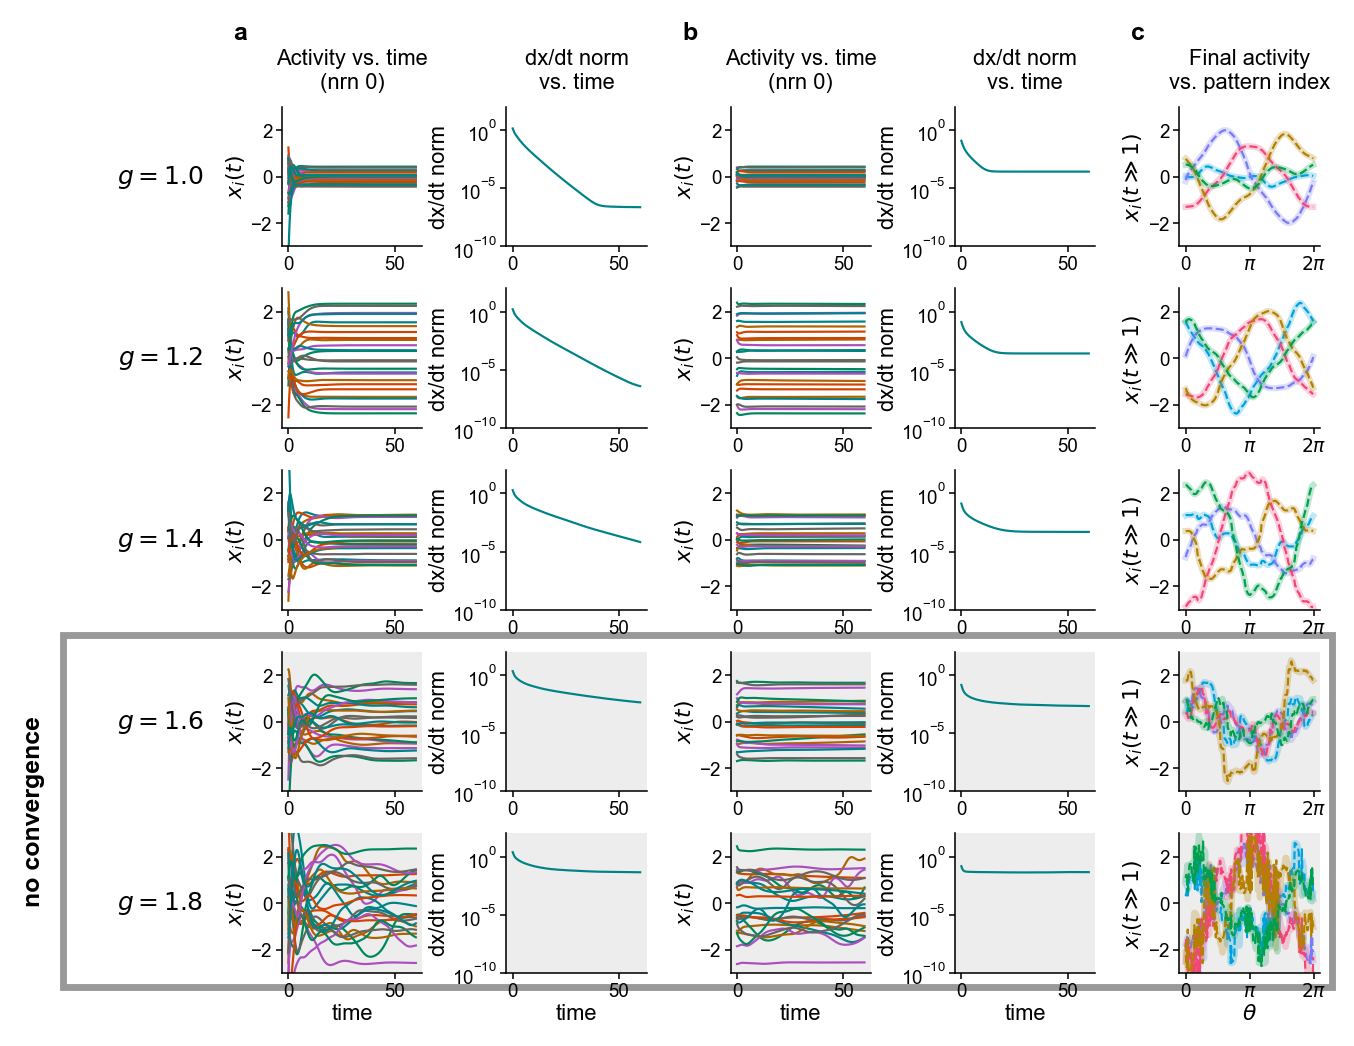

In [2]:
T, dt = 60, 0.1
g_vals = [1.0, 1.2, 1.4, 1.6, 1.8]  # List of g values to compare
N = 1000
K = 2
P = 250

# Setup figure with multiple rows
num_g = len(g_vals)
fig, axes = plt.subplots(num_g, 5, figsize=(style.FULL_W, num_g))
fig.subplots_adjust(wspace=0.6, hspace=0.3, left=0.26)

# Ensure axes is 2D even for single row
if num_g == 1:
    axes = axes.reshape(1, -1)

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

# Loop through different g values
for i, g in enumerate(g_vals):
    print(f"\n=== Processing g = {g} ===")

    # Initialize and train
    rnn = ReservoirRNN(N=N, g=g, K=K, P=P, embedding='fourier', device='cuda' if torch.cuda.is_available() else 'cpu')

    print("Training in open-loop mode...")
    X_open, norm_open = rnn.train_open_loop(T=T, dt=dt)

    print("Learning readout weights...")
    rnn.learn_readout_weights(lamda=1e-3)

    print("Running in closed-loop mode...")
    X_closed, norm_closed = rnn.run_closed_loop(T=T, dt=dt, noise_scale=0.1)

    # Visualize results for this g value
    print("Visualizing results...")

    # Add g value as title prefix for this row
    title_prefix = "" #f"g={g}: "

    # Training results (columns 0-1)
    neuron_idx = 0
    pattern_step = 10
    rnn._plot_activity_and_norm(
        axes[i, 0], axes[i, 1], X_open, norm_open, T, dt, 
        neuron_idx, pattern_step, title_prefix)
    # Closed-loop results (columns 2-3)  
    rnn._plot_activity_and_norm(
        axes[i, 2], axes[i, 3], X_closed, norm_closed, T, dt,
        neuron_idx, pattern_step, title_prefix)

    # Tuning curves (column 4)
    num_tcs_to_show = 5
    rnn.visualize_tuning_curves(
        axes[i, 4], X_closed=X_closed, 
        neuron_indices=np.linspace(0, N-1, num_tcs_to_show).astype(int))

for i in range(len(g_vals)):
    for j in range(5):
        ax = axes[i,j]
        if i != 0:
            ax.set_title("")
        if i != len(g_vals)-1:
            ax.set_xlabel("")
    

# --- annotations: gain labels + no-convergence box ---
import matplotlib.patches as _mpatches
for _i, _g in enumerate(g_vals):
    _p = axes[_i, 0].get_position()
    fig.text(_p.x0 - 0.075, (_p.y0 + _p.y1) / 2, f"$g = {_g}$",
             ha='center', va='center', fontsize=8, fontweight='bold')

# the last two gain values do not converge: grey the subplots and box the region
_nc = [i for i, g in enumerate(g_vals) if g >= 1.6]
for _i in _nc:
    for _j in range(5):
        axes[_i, _j].set_facecolor('0.93')
_pt = axes[_nc[0], 0].get_position()
_pb = axes[_nc[-1], 0].get_position()
_pr = axes[_nc[-1], 4].get_position()
_bx0, _bx1 = _pb.x0 - 0.135, _pr.x1 + 0.008
_by0, _by1 = _pb.y0 - 0.012, _pt.y1 + 0.015
fig.patches.append(_mpatches.Rectangle((_bx0, _by0), _bx1 - _bx0, _by1 - _by0,
    transform=fig.transFigure, facecolor='none', edgecolor=(0, 0, 0, 0.4), lw=2.2, zorder=5))
fig.text(_bx0 - 0.018, (_by0 + _by1) / 2, "no convergence", ha='center', va='center',
         fontsize=8, fontweight='bold', rotation=90)

# --- panel letters, one per functional block of columns ---
# a = open loop (columns 1 and 2), b = closed loop (columns 3 and 4),
# c = tuning curves (column 5). Placed above the column titles.
_letter_y = axes[0, 0].get_position().y1 + 0.055
for _letter, _col in zip("abc", (0, 2, 4)):
    fig.text(axes[0, _col].get_position().x0 - 0.030, _letter_y, _letter,
             ha='left', va='bottom', fontsize=8, fontweight='bold')

if SAVE_FIGURES:
    plt.savefig("../figures/reservoir_rnn_dynamics.png", bbox_inches='tight', dpi=300)
plt.show()